In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [2]:
# Load the datasets
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

In [3]:
# Convert date columns to datetime
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [4]:
# Calculate daily returns for each fund
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change())

In [5]:
# Check daily return distribution
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

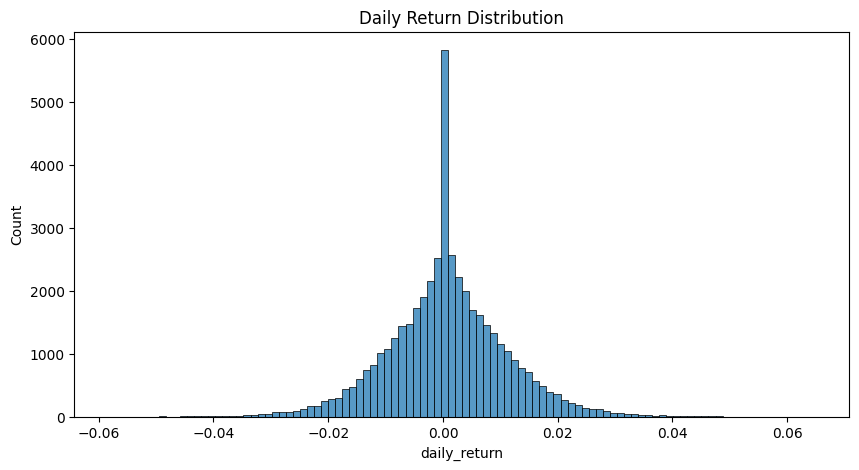

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(nav["daily_return"].dropna(),bins=100)
plt.title("Daily Return Distribution")
plt.show()

### Daily Return Analysis
Daily returns are centered around zero with occasional positive and negative spikes, indicating normal market fluctuations.

In [ ]:
# Calculate CAGR for each fund
cagr_data = []
for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]
    years = (temp["date"].max()-temp["date"].min()).days /365
    cagr = ((end_nav/start_nav)**(1/years)-1) * 100
    cagr_data.append([code, cagr])
cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code","cagr"]
)
cagr_df.head()

,amfi_code,cagr
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [8]:
# Calculate Sharpe Ratio for each fund
rf = 0.065
sharpe_data = []
for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    returns = temp["daily_return"].dropna()
    annual_return = (returns.mean()*252)
    annual_std = (returns.std()*np.sqrt(252))

    sharpe = (annual_return-rf)/annual_std
    sharpe_data.append([code, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [ ]:
# Calculate Sortino Ratio for each fund
sortino_data = []
for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    returns =temp["daily_return"].dropna()
    downside = returns[returns < 0]
    annual_return = returns.mean()*252
    downside_std =downside.std()*np.sqrt(252)

    sortino = (annual_return-rf)/downside_std
    sortino_data.append([code, sortino])

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [11]:
# Calculate benchmark returns
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [12]:
# Calculate alpha and beta for each fund
alpha_beta = []
for code in nav["amfi_code"].unique():
    fund = nav[nav["amfi_code"] == code]
    merged = pd.merge(
        fund[["date", "daily_return"]],
        nifty100[["date", "benchmark_return"]],
        on="date"
    )
    merged = merged.dropna()
    beta, intercept, r, p, std = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )
    alpha = intercept * 252
    alpha_beta.append([code, alpha, beta])
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [14]:
# Calculate maximum drawdown for each fund
drawdown_data = []
for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code].copy()
    temp["running_max"] = (temp["nav"].cummax())
    temp["drawdown"] = (temp["nav"]/temp["running_max"]) - 1

    max_dd = temp["drawdown"].min()

    drawdown_data.append([code, max_dd])
drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)
drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [15]:
# Create a scorecard by merging all metrics
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)
scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)
scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)
scorecard = scorecard.merge(
    fund_master[
        ["amfi_code",
         "expense_ratio_pct"]
    ],
    on="amfi_code"
)
scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct
0,100016,2.635246,-0.201517,0.037476,-0.058268,-0.247344,1.55
1,100025,4.455091,-0.567095,0.042818,0.001158,-0.043083,0.56
2,100033,30.099704,1.093699,0.271954,0.005104,-0.162172,1.38
3,101206,23.520489,1.027213,0.213998,0.021086,-0.112916,1.60
4,101207,7.933121,0.162661,0.108971,-0.065289,-0.354469,1.53


In [16]:
# Rank funds based on each metric (higher is better for return, sharpe, alpha; lower is better for expense and drawdown)
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(pct=True)
)
scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)
scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)
scorecard["expense_rank"] = (
    -scorecard["expense_ratio_pct"]
).rank(pct=True)
scorecard["dd_rank"] = (
    -scorecard["max_drawdown"]
).rank(pct=True)

In [17]:
# Calculate overall score (weighted average of ranks) formula: 0.30*return_rank + 0.25*sharpe_rank + 0.20*alpha_rank + 0.15*expense_rank + 0.10*dd_rank
scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["dd_rank"]
) * 100

In [ ]:
# Sort funds by score and display top 10
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)
scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,32.801599,1.180101,0.292636,0.000549,-0.181885,1.36,1.000,0.900,0.950,0.6500,0.625,87.5000
21,119598,32.398084,0.945308,0.303370,-0.023196,-0.287060,1.43,0.975,0.675,1.000,0.5000,0.900,82.6250
39,149324,32.262108,0.949796,0.300579,0.011455,-0.311719,1.52,0.950,0.700,0.975,0.3625,0.925,80.1875
30,120843,30.883326,1.306744,0.273305,-0.022830,-0.129740,1.45,0.875,0.975,0.900,0.4750,0.325,79.0000
2,100033,30.099704,1.093699,0.271954,0.005104,-0.162172,1.38,0.850,0.850,0.875,0.6000,0.500,78.2500
34,148567,30.949920,1.448291,0.269838,0.023684,-0.112657,1.46,0.900,1.000,0.850,0.4500,0.200,77.7500
36,148569,31.924486,1.234930,0.282704,0.018134,-0.163967,1.60,0.925,0.950,0.925,0.1125,0.525,76.9375
16,119094,28.192608,0.998231,0.260767,-0.066265,-0.209609,1.38,0.800,0.750,0.800,0.6000,0.700,74.7500
19,119551,25.784921,1.208267,0.232010,-0.031751,-0.150124,1.54,0.775,0.925,0.775,0.2625,0.425,70.0625
9,118632,24.031196,1.081659,0.218294,-0.008354,-0.174141,1.51,0.750,0.825,0.750,0.4125,0.575,70.0625


In [20]:
# Save the scorecard and alpha-beta data to CSV in reports folder
scorecard.to_csv(
    "../reports/day4_fund_scorecard.csv",
    index=False
)
alpha_beta_df.to_csv(
    "../reports/day4_alpha_beta.csv",
    index=False
)
print("Files Saved Successfully")

Files Saved Successfully


In [ ]:
# Display top 5 funds by AMFI code
top5 = scorecard.head(5)["amfi_code"].tolist()
print(top5)

[120505, 119598, 149324, 120843, 100033]


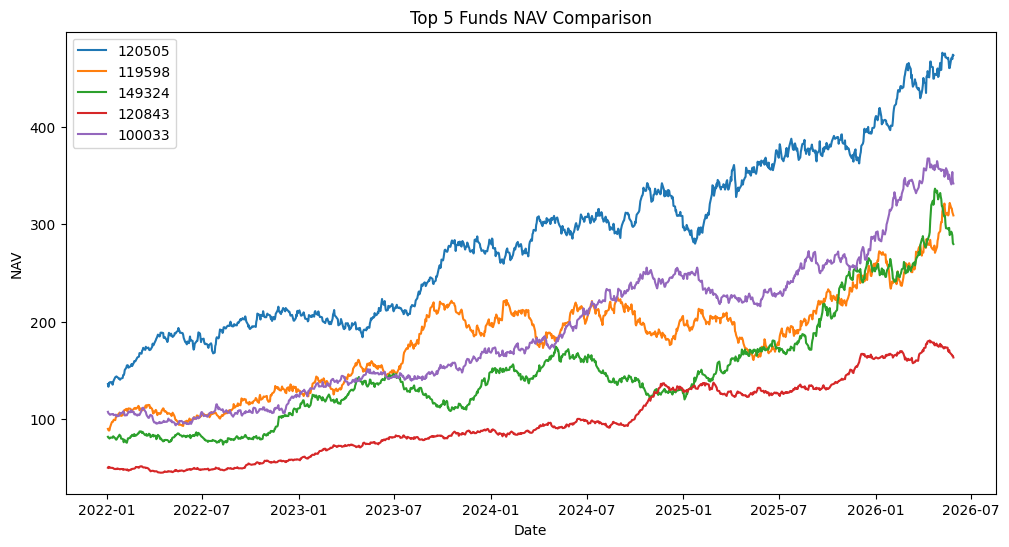

In [ ]:
# Plot NAV history for top 5 funds
plt.figure(figsize=(12,6))
for code in top5:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"],temp["nav"],label=str(code))
plt.title("Top 5 Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.show()

### Figure:
Top-performing funds showed a consistent upward NAV trend with varying levels of volatility.

In [24]:
# Calculate tracking error for top 5 funds (formula: TE = std((fund_return - benchmark_return)) * sqrt(252))
tracking_error = []
for code in top5:
    fund = nav[nav["amfi_code"] == code][["date","daily_return"]]
    merged = pd.merge(fund,nifty100[["date","benchmark_return"]],on="date")
    merged = merged.dropna()
    te = ((merged["daily_return"]-merged["benchmark_return"]).std()) * np.sqrt(252)
    tracking_error.append([code, te])
tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)
tracking_error_df

,amfi_code,tracking_error
0,120505,0.231968
1,119598,0.283881
2,149324,0.279170
3,120843,0.206425
4,100033,0.228699


In [25]:
tracking_error_df.to_csv(
    "../reports/day4_tracking_error.csv",
    index=False
)